<a href="https://colab.research.google.com/github/YongrongLu/XAI-case1/blob/main/assignments/machine_learning_court.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/machine_learning_court.ipynb)

# 👩‍⚖️ ⚖️ Machine Learning Court

This notebook provides base model training code for our three case scenarios:
1. **Loan Approval**
2. **Breast Cancer Misclassification**
3. **Recidivism Prediction**

> ⚠️ This notebook does **not** include XAI techniques (SHAP, LIME, Anchors). You are expected to implement those yourself based on the model and prediction tasks below.





## ⚖️ Case 1: Loan Denial Dispute – UCI Adult Income Dataset
#### 🔍 Scenario

Jane Dow, a 37-year-old professional woman with a Bachelor's degree and full-time executive role, applied for a premium credit product. The bank’s model—trained to predict income level as a proxy for eligibility—classified her as earning ≤$50K, resulting in denial. She disputes the fairness of the decision.

#### 🟥 Prosecution
Evaluate whether the model’s decision may have been influenced by inappropriate or unfair reasoning. Explore whether the explanation aligns with what should be expected in a fair credit decision.

#### 🟦 Defense
Justify the decision based on the model’s learned patterns. Consider how well the explanation supports the classification and whether similar profiles are treated consistently.

In [2]:
# 📦 Case 1: Loan Approval Prediction (Adult Income Dataset)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load Data
from sklearn.datasets import fetch_openml
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame

# Clean and preprocess
df = df.dropna()
df = df.copy()
encoders = {}
label_cols = [
    col for col in df.select_dtypes(include='category').columns
    if col != 'class'
]

for col in label_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop(["class", "fnlwgt"], axis=1)
y = df["class"].apply(lambda x: 1 if x == '>50K' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple RF model
model_adult = RandomForestClassifier(random_state=42)
model_adult.fit(X_train, y_train)
print(classification_report(y_test, model_adult.predict(X_test)))


              precision    recall  f1-score   support

           0       0.88      0.92      0.90      6842
           1       0.72      0.61      0.66      2203

    accuracy                           0.85      9045
   macro avg       0.80      0.77      0.78      9045
weighted avg       0.84      0.85      0.84      9045



In [3]:
# Explore the original data
print("Original dataset shape:", adult.frame.shape)
print("Rows after dropping missing values:", len(df))

display(adult.frame.head())

print("\nMissing values before cleaning:")
display(adult.frame.isna().sum())

print("\nTarget distribution: 0 = <=50K, 1 = >50K")
display(
    y.value_counts()
     .sort_index()
     .rename_axis("Class")
     .to_frame("Count")
)

print("\nModel input features:")
print(X_train.columns.tolist())

print("\nClasses learned by the model:")
print(model_adult.classes_)

assert set(y.unique()) == {0, 1}, "Check target encoding!"

Original dataset shape: (48842, 15)
Rows after dropping missing values: 45222


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K



Missing values before cleaning:


,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0



Target distribution: 0 = <=50K, 1 = >50K


,Count
Class,
0,34014
1,11208



Model input features:
['age', 'workclass', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Classes learned by the model:
[0 1]


In [4]:
# 🎯 Focus Instance: Loan Rejection Case (Jane Dow)

jane_encoded = {
    'age': 37,
    'workclass': encoders['workclass'].transform(['Private'])[0],
    'education': encoders['education'].transform(['Bachelors'])[0],
    'marital-status': encoders['marital-status'].transform(['Never-married'])[0],
    'occupation': encoders['occupation'].transform(['Exec-managerial'])[0],
    'relationship': encoders['relationship'].transform(['Not-in-family'])[0],
    'race': encoders['race'].transform(['White'])[0],
    'sex': encoders['sex'].transform(['Female'])[0],
    'hours-per-week': 50,
    'native-country': encoders['native-country'].transform(['United-States'])[0],
    'capital-gain': 0,
    'capital-loss': 0,
    'education-num': 13,
}

jane_df = pd.DataFrame([jane_encoded])
jane_df = jane_df[X_train.columns]
pred = model_adult.predict(jane_df)
print("Prediction for Jane Dow (Loan Eligibility):", "Approved" if pred[0] == 1 else "Denied")


Prediction for Jane Dow (Loan Eligibility): Denied


In [5]:
# Display Jane's profile using readable category names
jane_readable = jane_df.copy()

for col in jane_readable.columns:
    if col in encoders:
        jane_readable[col] = encoders[col].inverse_transform(
            jane_df[col].astype(int)
        )

display(jane_readable.T.rename(columns={0: "Jane"}))

# Inspect predicted probabilities
probabilities = model_adult.predict_proba(jane_df)[0]

for label, probability in zip(model_adult.classes_, probabilities):
    income_group = ">50K" if label == 1 else "<=50K"
    print(f"P(income {income_group}) = {probability:.3f}")

,Jane
age,37
workclass,Private
education,Bachelors
education-num,13
marital-status,Never-married
occupation,Exec-managerial
relationship,Not-in-family
race,White
sex,Female
capital-gain,0


P(income <=50K) = 0.697
P(income >50K) = 0.303


### Data exploration and model validation

The dataset contains 48,842 records, with 45,222 remaining after
dropping missing values. Approximately 75.2% of these records belong
to the <=50K class, indicating class imbalance.

I corrected a target-encoding bug in the starter notebook by excluding
`class` from feature label encoding. Otherwise, comparing the encoded
target against the string '>50K' would produce an all-zero target.

The random forest achieved approximately 85% test accuracy, but recall
for the >50K class was only 61%, indicating that it missed a substantial
portion of higher-income individuals.

For Jane, the model predicted P(income >50K) = 0.303 and classified her
as <=50K, resulting in denial under the scenario's eligibility rule.
These are model estimates, not verified probabilities of Jane's actual
income or repayment ability.


In [6]:
%pip -q install shap

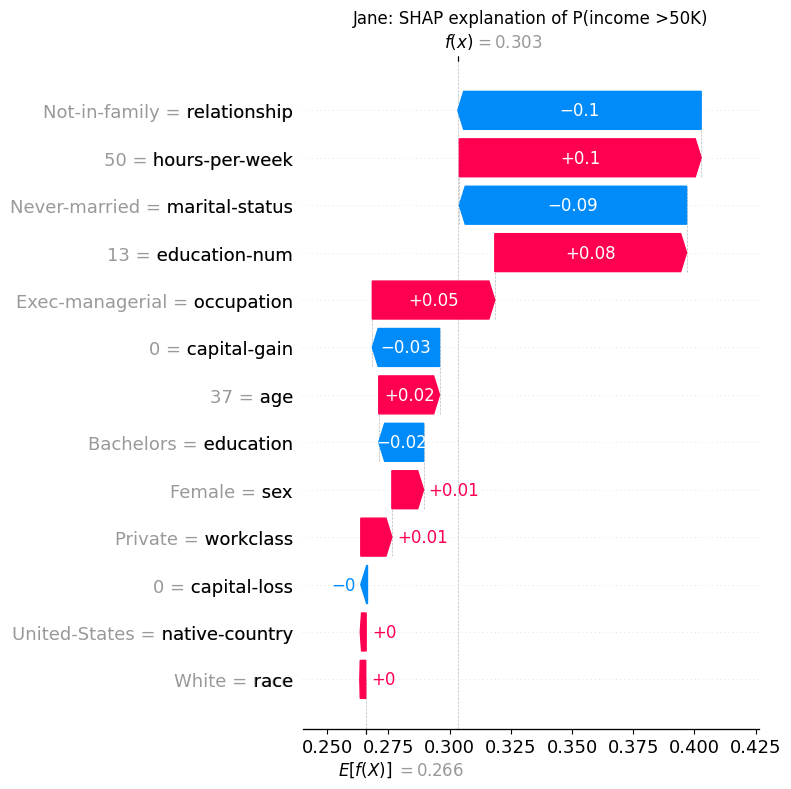

Background baseline: 0.2657
Baseline + SHAP contributions: 0.3033
Model P(income >50K): 0.3033


,Feature,Jane's value,SHAP contribution
6,relationship,Not-in-family,-0.099427
11,hours-per-week,50,0.098784
4,marital-status,Never-married,-0.092830
3,education-num,13,0.078349
5,occupation,Exec-managerial,0.050043
9,capital-gain,0,-0.027464
0,age,37,0.024829
2,education,Bachelors,-0.018327
8,sex,Female,0.012971
1,workclass,Private,0.012696


In [10]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Use training data as the reference background
background = X_train.sample(n=100, random_state=42)

explainer = shap.TreeExplainer(
    model_adult,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

# Explain Jane's probability of income >50K
class_index = list(model_adult.classes_).index(1)
shap_results = explainer(jane_df)
jane_shap = shap_results[0, :, class_index]

# Show readable category names instead of encoded numbers
readable_values = jane_df.iloc[0].astype(object).copy()

for col in jane_df.columns:
    if col in encoders:
        readable_values[col] = encoders[col].inverse_transform(
            [int(jane_df.iloc[0][col])]
        )[0]

plot_explanation = shap.Explanation(
    values=jane_shap.values,
    base_values=float(jane_shap.base_values),
    data=readable_values.to_numpy(),
    feature_names=jane_df.columns.tolist()
)

shap.plots.waterfall(
    plot_explanation,
    max_display=len(jane_df.columns),
    show=False
)
plt.title("Jane: SHAP explanation of P(income >50K)")
plt.tight_layout()
plt.show()

# Check that the contributions reconstruct the model prediction
baseline = float(jane_shap.base_values)
reconstructed = baseline + jane_shap.values.sum()
predicted = model_adult.predict_proba(jane_df)[0, class_index]

print(f"Background baseline: {baseline:.4f}")
print(f"Baseline + SHAP contributions: {reconstructed:.4f}")
print(f"Model P(income >50K): {predicted:.4f}")

assert np.isclose(reconstructed, predicted, atol=1e-5)

# Rank feature contributions by magnitude
shap_table = pd.DataFrame({
    "Feature": jane_df.columns,
    "Jane's value": readable_values.to_numpy(),
    "SHAP contribution": jane_shap.values
})

shap_table = shap_table.iloc[
    np.argsort(-np.abs(jane_shap.values))
]

display(shap_table)

### SHAP interpretation

Using 100 training records as the background, the baseline predicted
probability of income >50K was 0.2657. SHAP contributions increased
this to 0.3033 for Jane, matching the random forest's prediction.

The strongest negative contributions were relationship = Not-in-family
(-0.0994) and marital-status = Never-married (-0.0928). The strongest
positive contributions were working 50 hours per week (+0.0988),
education-num = 13 (+0.0783), and an executive/managerial occupation
(+0.0500).

The reliance on marital status and relationship raises fairness
questions when income prediction is used for credit eligibility.
However, this explanation alone does not establish discrimination.

Moreover, the Female feature had a small positive contribution (+0.0130) in
this explanation, so it does not support the claim that Jane was
denied because she is female.

Education and education-num encode related information, so their
individual contributions should be interpreted cautiously.
These attributions explain the model relative to the selected
background; they do not establish causal effects or repayment ability.

In [8]:
%pip -q install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


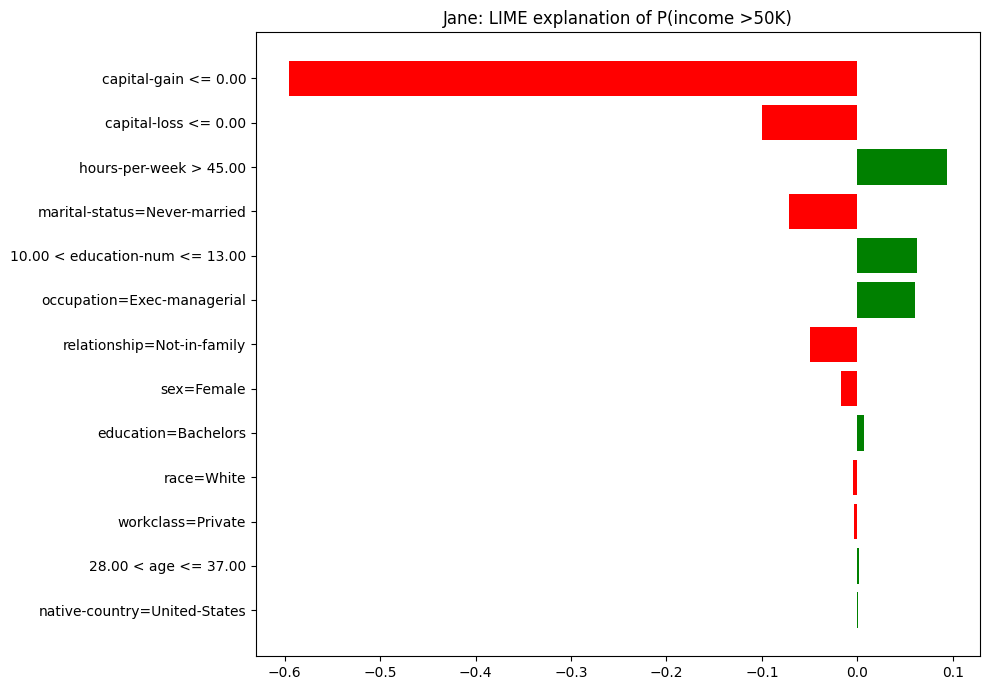

,Feature condition,LIME weight
0,capital-gain <= 0.00,-0.595569
1,capital-loss <= 0.00,-0.100061
2,hours-per-week > 45.00,0.094009
3,marital-status=Never-married,-0.071350
4,10.00 < education-num <= 13.00,0.062015
5,occupation=Exec-managerial,0.060544
6,relationship=Not-in-family,-0.049591
7,sex=Female,-0.017154
8,education=Bachelors,0.006441
9,race=White,-0.004436


Random forest probability: 0.3033
LIME local approximation: 0.2510
Absolute difference: 0.0523
LIME weighted R²: 0.5440


In [12]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X_train.columns.tolist()

# Identify categorical columns and their readable labels
categorical_features = [
    i for i, col in enumerate(feature_names)
    if col in encoders
]

categorical_names = {
    i: encoders[feature_names[i]].classes_.tolist()
    for i in categorical_features
}

# Preserve feature names when passing LIME samples to the model
def predict_for_lime(samples):
    samples_df = pd.DataFrame(samples, columns=feature_names)
    return model_adult.predict_proba(samples_df)

lime_explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(dtype=float),
    feature_names=feature_names,
    class_names=[
        ">50K" if label == 1 else "<=50K"
        for label in model_adult.classes_
    ],
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

class_index = list(model_adult.classes_).index(1)

lime_result = lime_explainer.explain_instance(
    data_row=jane_df.iloc[0].to_numpy(dtype=float),
    predict_fn=predict_for_lime,
    labels=(class_index,),
    num_features=len(feature_names),
    num_samples=5000
)

# Plot the explanation for the same class used in SHAP
fig = lime_result.as_pyplot_figure(label=class_index)
fig.set_size_inches(10, 7)
plt.title("Jane: LIME explanation of P(income >50K)")
plt.tight_layout()
plt.show()

# Display the local explanation weights
lime_table = pd.DataFrame(
    lime_result.as_list(label=class_index),
    columns=["Feature condition", "LIME weight"]
)
display(lime_table)

# Assess how well LIME approximates the random forest
actual_probability = predict_for_lime(
    jane_df.to_numpy(dtype=float)
)[0, class_index]

local_probability = float(
    np.asarray(lime_result.local_pred).ravel()[0]
)

print(f"Random forest probability: {actual_probability:.4f}")
print(f"LIME local approximation: {local_probability:.4f}")
print(f"Absolute difference: {abs(actual_probability - local_probability):.4f}")
print(f"LIME weighted R²: {lime_result.score:.4f}")

### LIME interpretation

LIME identified capital-gain as the strongest negative condition
(weight = -0.5956). Other negative conditions included zero capital
loss, Never-married, and Not-in-family. Working more than 45 hours
per week, the education-num interval containing Jane's value, and
an executive/managerial occupation supported the >50K prediction.

The LIME predicted 0.2510, compared with the random
forest's 0.3033, an absolute difference of 0.0523.  The weighted R² was 0.5440, so LIME did not explain the model’s behavior very closely in the generated samples.
The weights should therefore be interpreted as an approximate local
description, not exact contributions to the random forest prediction.

### Comparison of SHAP and LIME

Both methods assigned positive effects to working hours,
education-num, and occupation, and negative effects to marital status,
relationship, and zero capital gain. This agreement supports these
as relevant factors under the two explanation approaches.

However, their rankings differed. SHAP ranked relationship as the
largest negative contribution, whereas LIME emphasized zero capital
gain. The Female feature also changed sign: positive in SHAP and
negative in LIME, with relatively small magnitudes in both.

SHAP decomposes the prediction relative to a selected background,
whereas LIME fits a linear approximation using perturbed samples
and discretized conditions. Their values are not directly
interchangeable. LIME's limited fidelity further weakens conclusions
based on its individual weights.

Correlated features, including education and education-num, complicate
interpretation. Perturbations may also produce unrealistic feature
combinations. Neither explanation establishes causal effects.

### Conclusion and fairness considerations

The model predicted a 30.33% chance that Jane earns more than $50K, so she was denied in this case. Both SHAP and LIME showed that her working hours, education level, and management job helped her prediction. Being unmarried and having the relationship category “Not-in-family” impact negatively.

For the prosecution, I think using marital status and family relationship for a credit decision raises fairness concerns. Also, predicting income is not the same as predicting whether someone can repay a loan.

For the defense, the model did consider her positive qualifications, but the final prediction was still below 50%. This helps explain the decision, but it does not prove the decision was fair.

It can't be concluded that Jane was denied because she is female. SHAP showed a small positive effect for this feature, while LIME showed a small negative effect. LIME also did not match the model very closely. We would need to compare more people and similar profiles before making a stronger conclusion about fairness.


## 🩺 Case 2: Tumor Misclassification – Breast Cancer Dataset
#### 🔍 Scenario
Patient X received a benign classification from an AI tumor diagnostic tool and was not referred for a biopsy. Months later, the tumor was diagnosed as malignant. The model’s output is now under scrutiny.

#### 🟥 Prosecution
Use explanation tools to evaluate how the model arrived at this decision. Consider whether any key medical indicators might have been overlooked or minimized.

#### 🟦 Defense
Defend the decision with reference to the model’s logic and learned feature importance. Consider how this decision aligns with the broader data trends.

In [ ]:
# 🧬 Case 2: Tumor Misclassification (Breast Cancer Dataset)
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Load dataset
data = load_breast_cancer()
df_bc = pd.DataFrame(data.data, columns=data.feature_names)
df_bc['target'] = data.target  # 0 = malignant, 1 = benign

# Train/test split
X = df_bc.drop("target", axis=1)
y = df_bc["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model_bc = RandomForestClassifier(random_state=42)
model_bc.fit(X_train, y_train)
print(classification_report(y_test, model_bc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
# 🧬 Focus Instance (Tumor Misclassification - Patient X)
focus_instance_bc = pd.DataFrame([{
    "mean radius": 13.80,
    "mean texture": 15.79,
    "mean perimeter": 90.43,
    "mean area": 584.1,
    "mean smoothness": 0.1007,
    "mean compactness": 0.1280,
    "mean concavity": 0.07789,
    "mean concave points": 0.05069,
    "mean symmetry": 0.1662,
    "mean fractal dimension": 0.06566,
    "radius error": 0.4101,
    "texture error": 1.074,
    "perimeter error": 2.635,
    "area error": 40.14,
    "smoothness error": 0.00541,
    "compactness error": 0.02204,
    "concavity error": 0.01664,
    "concave points error": 0.01185,
    "symmetry error": 0.02095,
    "fractal dimension error": 0.004902,
    "worst radius": 16.57,
    "worst texture": 20.86,
    "worst perimeter": 110.3,
    "worst area": 812.4,
    "worst smoothness": 0.1411,
    "worst compactness": 0.3542,
    "worst concavity": 0.2779,
    "worst concave points": 0.1383,
    "worst symmetry": 0.2589,
    "worst fractal dimension": 0.1030
}])

# Run prediction
pred = model_bc.predict(focus_instance_bc)
print("Prediction for Patient X:", "Benign → No Biopsy" if pred[0] == 1 else "Malignant → Action Needed")


Prediction for Patient X: Benign → No Biopsy


## ⚖️ Case 3: Recidivism Risk – COMPAS Dataset
#### 🔍 Scenario
Malik Johnson, a 27-year-old with one prior felony, was flagged as low risk by an AI risk assessment tool and granted parole. Some community stakeholders have questioned whether this was an appropriate classification.

#### 🟥 Prosecution
Examine whether the model may have underestimated risk factors. Use explanation techniques to uncover potential oversights or inconsistencies.

#### 🟦 Defense
Argue that the decision was reasonable based on the model's criteria. Use explanation tools to show which features were most influential and whether the classification aligns with data-driven patterns.

In [ ]:
# ⚖️ Case 3: Recidivism Prediction (COMPAS Dataset)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_compas = pd.read_csv(url)

# Filter relevant columns and preprocess
features = ['age', 'sex', 'race', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree']
df = df_compas[features + ['two_year_recid']].dropna()
df = df[df['c_charge_degree'].isin(['F', 'M'])]  # Filter valid degrees

# Encode categoricals
df = df.copy()
df['sex'] = df['sex'].astype('category').cat.codes
df['race'] = df['race'].astype('category').cat.codes
df['c_charge_degree'] = df['c_charge_degree'].astype('category').cat.codes

X = df[features]
y = df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_compas = RandomForestClassifier(random_state=42)
model_compas.fit(X_train, y_train)
print(classification_report(y_test, model_compas.predict(X_test)))


              precision    recall  f1-score   support

           0       0.68      0.68      0.68       823
           1       0.57      0.57      0.57       620

    accuracy                           0.63      1443
   macro avg       0.62      0.62      0.62      1443
weighted avg       0.63      0.63      0.63      1443



In [ ]:
# 🎯 Focus Instance: Recidivism Risk Case (Malik Johnson)
focus_instance_compas = pd.DataFrame([{
    "age": 27,
    "sex": 1,  # Male
    "race": 1,  # African-American
    "priors_count": 1,
    "juv_fel_count": 0,
    "juv_misd_count": 0,
    "juv_other_count": 0,
    "c_charge_degree": 1  # Felony
}])

pred = model_compas.predict(focus_instance_compas)
print("Prediction for Malik Johnson (Recidivism):", pred)


Prediction for Malik Johnson (Recidivism): [0]
